In [527]:
#pip install hyperopt jupyter matplotlib pandas requests reservoirpy scikit-learn seaborn brevitas fxpmath

# Classification with Reservoir Computing

Reservoir Computing (RC) is well suited to both regression and classification tasks. In the following notebook, you will experiment with a simple example of classification task.

In [528]:
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np
import reservoirpy as rpy

from reservoirpy.nodes import Reservoir, Ridge, Input
from reservoirpy.datasets import japanese_vowels
from reservoirpy import set_seed, verbosity
from reservoirpy.observables import nrmse, rsquare

from sklearn.metrics import accuracy_score

set_seed(42)
verbosity(0)

0

In [529]:
import numpy as np
from aeon.datasets import load_classification
from tensorflow.keras.utils import to_categorical
import reservoirpy as rp
import reservoirpy.nodes as rpn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Set up reservoirpy parameters and configurations
rp.verbosity(0)  # No verbosity for clean output
rp.set_seed(42)  # Set random seed for reproducibility

# Load the training and testing data for the 'ECG200' dataset
X_train, y_train = load_classification('GunPoint', split='train')
X_test, y_test = load_classification('GunPoint', split='test')
# X_train, y_train = load_classification('Chinatown', split='train')
# X_test, y_test = load_classification('Chinatown', split='test')
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

# Check the unique labels in y
unique_labels = np.unique(y_train)
print(f"Unique labels in y_train: {unique_labels}")

# Convert string labels to integers using LabelEncoder
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)  # Use the same encoder to transform test labels

# One-hot encode the labels for the classification task
y_train_cat = to_categorical(y_train, num_classes=len(unique_labels))
y_test_cat = to_categorical(y_test, num_classes=len(unique_labels))

# Reshape the data to match the expected input shape (n_samples, n_features)
X_train_reshaped = X_train.reshape(X_train.shape[0], X_train.shape[2])  # Convert to 2D shape (samples, features)
X_test_reshaped = X_test.reshape(X_test.shape[0], X_test.shape[2])  # Convert to 2D shape (samples, features)

# Set up a range of N values to test
N_values = [250]  # Test N from 100 to 500
accuracies = []  # List to store the accuracy for each N

# Loop through different values of N
for N in N_values:
    print(f"\nTraining and evaluating model with N = {N} reservoir units...")
    
    # Build the Reservoir Computing Model
    reservoir = rpn.Reservoir(
        units=N,                # Number of reservoir neurons
        input_dim=X_train_reshaped.shape[1],  # Each time step in the time series is a vector of length n_features
        sr=0.3,                 # Spectral radius (for the echo state property)
        input_connectivity=0.9, # Spectral radius for input weights
        rc_connectivity=0.1,    # Reservoir internal connectivity
        input_scaling=0.01,     # Scaling for the input weights
        lr=0.4,                 # Leaking rate (1.0 for non-leaky units)
        seed=45               # For reproducibility
    )

    # Create a Ridge regression readout node with the regularization parameter
    readout = rpn.Ridge(ridge=1e-1)

    # Build a pipeline: the reservoir feeds its output into the readout
    esn_model = reservoir >> readout

    # Train the Model
    esn_model.fit(X_train_reshaped, y_train_cat)

    # Evaluate the Model
    y_pred = esn_model.run(X_test_reshaped)

    # Convert the network outputs (continuous predictions) to class labels
    y_pred_labels = np.argmax(y_pred, axis=1)

    # Since y_test is already one-hot encoded, we need to convert it to the same format for comparison
    y_test_labels = np.argmax(y_test_cat, axis=1)

    # Compute the accuracy of the model
    accuracy = np.mean(y_pred_labels == y_test_labels)  # Correct accuracy calculation
    accuracies.append(accuracy)  # Store the accuracy for this N

    print(f"Test accuracy for N={N}: {accuracy * 100:.2f}%")

# Plot the results
# plt.figure(figsize=(10, 6))
# plt.plot(N_values, accuracies, marker='o', linestyle='-', color='b')
# plt.title('Accuracy vs. Reservoir Size (N)', fontsize=14)
# plt.xlabel('Number of Reservoir Units (N)', fontsize=12)
# plt.ylabel('Test Accuracy (%)', fontsize=12)
# plt.grid(True)
# plt.show()

# Print the best result
best_N = N_values[np.argmax(accuracies)]
best_accuracy = max(accuracies)
print(f"Best accuracy: {best_accuracy * 100:.2f}% with N = {best_N}")


X_train shape: (50, 1, 150), y_train shape: (50,)
X_test shape: (150, 1, 150), y_test shape: (150,)
Unique labels in y_train: ['1' '2']

Training and evaluating model with N = 250 reservoir units...
Test accuracy for N=250: 68.00%
Best accuracy: 68.00% with N = 250


In [530]:
X= np.append(X_train_reshaped, X_test_reshaped, axis=0)

In [531]:
esn_model = esn_model.fit(X_train_reshaped, y_train_cat)
 #states of each time stamp over test set
reservoir_states_test = reservoir.run(X_test)  # Shape: (time_steps, num_neurons).
reservoir_states_test.shape
np.save('reservoir_states_test', reservoir_states_test)
output_test = readout.run(reservoir_states_test)  # Shape: (time_steps, output_dim)
output_test.shape
output_test = np.argmax(output_test, axis=1)
np.save('output_test', output_test)

In [532]:
# import matplotlib.pyplot as plt
# import numpy as np
# import torch
# import torch.nn as nn
# import torch.optim as optim
# from brevitas.nn import QuantHardTanh, QuantIdentity, QuantLinear
# from brevitas.quant import Int8ActPerTensorFloat, Int8WeightPerTensorFloat
# from reservoirpy.datasets import mackey_glass
# from reservoirpy.nodes import Reservoir, Ridge
# from reservoirpy.observables import rmse, rsquare
# from reservoirpy import Node
# import reservoirpy as rpy
# rpy.verbosity(0)
# rpy.set_seed(42)
# # pruned_res_size = len(ind)
# #N = 100
# # # Parameters
# # N = pruned_res_size #reservoir size
# bit_width = 8 # quantization bit width
# #integer, out , scale,  quantizer, layer , ...
# # input

# from brevitas.nn import QuantIdentity
# import math
# def extract_Qinput(input, num_bits=8):
#   quant_identity = QuantIdentity(return_quant_tensor=True,bit_width=num_bits)
#   float_input = torch.tensor(input,dtype=torch.float64)
#   quant_input = quant_identity(float_input)
#   out = quant_input.int().detach().numpy()

#   scale = quant_input.scale.detach().numpy()
#   zero_point = quant_input.zero_point.numpy()
#   print(f"Input int quantized:\n {out} \n")
#   print(f"Input scale: {scale}")
#   print(f"Input zero_point: {zero_point}")
#   return out, scale, zero_point
# from brevitas.nn import QuantLinear
# from brevitas.quant import Int8ActPerTensorFloat,Int8WeightPerTensorFloat
# import math


# def quantize_output_layer(weights, num_bits=8):
#   quant_linear = QuantLinear(2, 4,weight_bit_width=num_bits, weight_quant=Int8WeightPerTensorFloat, requires_grad=False)
#   quant_linear.weight.data = torch.tensor(weights,dtype=torch.float64)

#   out = quant_linear.quant_weight().int().detach().numpy()
#   scale = quant_linear.quant_weight().scale.detach().numpy()
#   # out = quant_linear.quant_weight().value.data.numpy()


#   #out = out * 0

#   return out,scale

# int_x,x_scale,x_zero_point = extract_Qinput(X,num_bits=bit_width)
# # np.savetxt('input_data.csv', int_x[5002:], fmt='%s', delimiter=',')
# print('Extract quantized integer Win and Scale and Zero_point')
# int_Win,scale_Win,zero_point_Win = extract_Qinput(esn_model.nodes[0].Win.todense(),num_bits=bit_width)
# print('Extract quantized integer Wr and Scale and Zero_point')
# int_Wr,scale_Wr,zero_point_Wr = extract_Qinput(esn_model.nodes[0].W.todense(),num_bits=bit_width)
# int_bias, scale_bias, zero_point_bias = extract_Qinput(esn_model.nodes[0].bias.todense(), num_bits=bit_width)


# input_scale = (scale_Win * x_scale)
# threshold_scale = 0.0078125
# reservoir_scale = (scale_Wr * threshold_scale)

# def compute_integer_thresholds(scale):

#     a = -1  # Lower bound of Hard Tanh
#     b = 1   # Upper bound of Hard Tanh
#     a_scaled = np.int32(a / scale)
#     b_scaled = np.int32(b / scale)
#     return a_scaled, b_scaled

# def piecewise_linear_hard_tanh_integer(x, a_scaled, b_scaled):

#     # Apply saturation logic
#     x = np.where(x < a_scaled, a_scaled, x)
#     x = np.where(x > b_scaled, b_scaled, x)
#     x=x + b_scaled
#     return (x / 256).astype(np.int32)

# a_scaled, b_scaled = compute_integer_thresholds(input_scale)
# c_scaled, d_scaled = compute_integer_thresholds(reservoir_scale)

# from reservoirpy import Node
# def forward2(node: Node, x: np.ndarray) -> np.ndarray:
#     state = node.state()  # get current node state  # Current reservoir state as integer
#     state_int = state.astype(np.int64)
#     W_res = node.Wr
#     W_in = node.Win
#     bias_res = node.Bias
#     state_int = state_int.reshape(1,N)

#     r = state_int @ W_res.astype(np.int32)
#     s = x @ W_in.astype(np.int32).T
#     s = s.reshape(1,N)
#     # Precompute thresholds and scale
#     # a_scaled, b_scaled = compute_integer_thresholds(scale_Wr)
#     bias_res = bias_res.reshape(1, N)



#     # Apply integer PLA to reservoir and input contributions
#     out_r = piecewise_linear_hard_tanh_integer(s,a_scaled, b_scaled)
#     out_s = piecewise_linear_hard_tanh_integer(r,c_scaled, d_scaled)

#     return out_r + out_s 

# def initialize(node: Node, x: np.ndarray = None, y: np.ndarray = None):
#     """This function receives a data point x at runtime and uses it to
#     infer input and output dimensions.
#     """
#     if x is not None:
#         node.set_input_dim(x.shape[1])
#         node.set_output_dim(N)
#         node.set_param("Wr", int_Wr)
#         node.set_param("Win", int_Win)
#         node.set_param("Bias", int_bias)

# class CustomNode(Node):
#     def __init__(self, const2=-1, name=None):
#         super().__init__(
#             forward=forward2,
#             initializer=initialize,

#             params={"const1": None, "Wr":None, "Win":None, "Bias":None},
#             hypers={"const2": const2},
#             name=name,
#         )

# node = CustomNode(const2=-1, name="custom_node3")
# # readout_pruned.ridge = 1e-12

# esn_model_PTQ = node >> readout

# Quantized_States = node.run(int_x[:1000].astype(np.float64))

# Quantized_States = Quantized_States * threshold_scale
# readout.fit(Quantized_States.astype(np.float64), y_train_cat)
# # esn_model_PTQ = node >> readout_pruned

# # esn_model_PTQ = esn_model_PTQ.fit(int_x[:5000].astype(np.float64), int_x[1:5001].astype(np.float64), warmup=1000)

# Quantized_States = node.run(int_x[1000:].astype(np.float64))
# Quantized_States = Quantized_States * threshold_scale
# Y_pred_PTQ_origin = readout.run(Quantized_States.astype(np.float64))

# Y_pred_PTQ_origin = np.argmax(Y_pred_PTQ_origin, axis=1)
# accuracy_PTQ_origin = np.mean(Y_pred_PTQ_origin == y_test_labels)
# print(f"Test accuracy Quantized Original: {accuracy_PTQ_origin * 100:.5f}%")



In [533]:
from reservoirpy.nodes import Reservoir
rpy.verbosity(0)  # no need to be too verbose here
rpy.set_seed(42)  # make everything reproducible!

def create_new_reservoir(model, pruned_W, pruned_W_in, pruned_bias):


    # Create a new reservoir with the pruned configuration
    pruned_reservoir = Reservoir(
        len(pruned_bias.todense()),
        lr=model.nodes[0].lr,
        sr=model.nodes[0].sr,
        input_connectivity=model.nodes[0].input_connectivity,
        # rc_connectivity=model.nodes[0].rc_connectivity,
        input_scaling=(model.nodes[0].input_scaling),
        input_dim=model.nodes[0].input_dim
    )

    # Assign the pruned weights to the new reservoir
    pruned_reservoir.W = pruned_W
    pruned_reservoir.Win = pruned_W_in
    # pruned_reservoir.bias = pruned_bias

    return pruned_reservoir

In [534]:
# ///////////////////////////////////////HSIC_Lasso\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\\
def HSIC_Prune():
    import numpy as np
    from pyHSICLasso import HSICLasso
    from sklearn.linear_model import LinearRegression
    from sklearn.metrics import mean_squared_error
    from sklearn.model_selection import train_test_split
    n, d = 4999, N  # n samples, d features
    np.random.seed(0)
    M = reservoir_states_test # Input matrix -> here should be the outcome of neurons
    y = output_test # Output of the ESN network

    # Your target RMSE
    target_rmse = 0.1  # Adjust this value based on your requirement
    tolerance = 0.1   # Acceptable tolerance around the target RMSE

    M_train, M_test, y_train, y_test = train_test_split(M, y, test_size=0.5, random_state=42)

    # Iterate over the number of features
    best_features = None
    best_rmse_diff = float(0.5)  # Difference between current RMSE and target RMSE
    int_list_temp=[]
    for num_features in range(1, d):
        print(num_features)
        hsic_lasso = HSICLasso()

        # Run HSIC Lasso to select a specific number of features
        hsic_lasso.input(M_train, y_train.reshape(-1))
        hsic_lasso.regression(num_feat=num_features)
        # hsic_lasso.plot()
        hsic_lasso.dump()

        selected_indices = hsic_lasso.get_features()
        selected_indices_temp = set(map(int, selected_indices))
        for i in range(len(selected_indices)):
            selected_indices_temp.update(hsic_lasso.get_index_neighbors(feat_index=i,num_neighbors=10))
            # selected_indices.append(hsic_lasso.get_index_neighbors(feat_index=i,num_neighbors=5))
        selected_indices = sorted(list(selected_indices_temp))
        if not selected_indices:  # Skip iteration if no features were selected
            continue
        # print(f"selected_indices: {selected_indices}")
        model = LinearRegression()
        int_list = list(map(int, selected_indices))
        if (int_list==int_list_temp):
            break
        print(f"int_list: {int_list}")
        ind = [x - 1 for x in int_list]
        print(f"ind: {ind}")
        int_list_temp=int_list
        model.fit(M_train[:, ind], y_train.reshape(-1))

        # Calculate RMSE on the test set
        y_pred = model.predict(M_test[:, ind])
        rmse_hsic = np.sqrt(mean_squared_error(y_test, y_pred))
        print(f"Found features with num_features={num_features}, RMSE={rmse_hsic} within tolerance of target RMSE.")
    new_size = len(ind)
    print("New reservoir size",len(ind))
    prune_count = new_size

    keep_neurons = ind
    pruned_W = esn_model.nodes[0].W[keep_neurons][:, keep_neurons]
    pruned_W_in = esn_model.nodes[0].Win[keep_neurons, :]
    pruned_W_out = esn_model.nodes[1].Wout[keep_neurons, :]
    pruned_bias = esn_model.nodes[0].bias[keep_neurons,:]

    reservoir_pruned = create_new_reservoir(esn_model, pruned_W, pruned_W_in, pruned_bias)

    readout_pruned = Ridge(ridge=readout.ridge)
    # readout_pruned.bias=readout.bias
    esn_model_pruned = reservoir_pruned >> readout_pruned

    readout_pruned.Wout=pruned_W_out
    # readout_pruned.bias = readout.bias
    esn_model_pruned=esn_model_pruned.fit(X_train_reshaped, y_train_cat)
    Y_pred_pruned = esn_model_pruned.run(X_test_reshaped)


    reservoir_pruned.W = pruned_W
    reservoir_pruned.Win = pruned_W_in
    reservoir_pruned.bias = pruned_bias
    esn_model_pruned=esn_model_pruned.fit(X_train_reshaped, y_train_cat)
    Y_pred_pruned = esn_model_pruned.run(X_test_reshaped)
    
    # Main ERROR
    Y_pred_pruned = np.argmax(Y_pred_pruned, axis=1)
    
    from sklearn.metrics import mean_squared_error # Import mean_squared_error from sklearn.metrics
    import math # Import math library

    print(reservoir_pruned.units)

    accuracy_pruned = np.mean(Y_pred_pruned == y_test_labels)
    print(f"Test accuracy HSIC Pruning: {accuracy * 100:.5f}%")
    return accuracy_pruned,prune_count,num_features

In [535]:
# ///////////////////////////////////////////////////Spearman////////////////////////////////////////////
# /////////////////////////////////////////////
# Calculate Spearman correlation between each neuron's state and the output
# prune_percentage_spearman=0.5
from scipy.stats import spearmanr
def spearman_Prune(prune_count,num_features):

    correlations = []
    for neuron_index in range(states.shape[1]):
    # Compute Spearman correlation between this neuron's state and the output
        corr, _ = spearmanr(states[:num_features, neuron_index], Y_pred[:num_features])  # Assuming single output dim
        correlations.append(corr)

    # Convert list to numpy array for sorting
    correlations = np.array(correlations)
    correlations[np.isnan(correlations)] = 0

    # Calculate the number of neurons to prune
    num_neurons = len(correlations)

    # Find indices of neurons with lowest correlations
    prune_indices = np.argsort(correlations)[:prune_count]
    keep_neurons = np.setdiff1d(np.arange(N), prune_indices)

    pruned_W = esn_model.nodes[0].W[keep_neurons][:, keep_neurons]
    pruned_W_in = esn_model.nodes[0].Win[keep_neurons, :]
    pruned_W_out = esn_model.nodes[1].Wout[keep_neurons, :]
    pruned_bias = esn_model.nodes[0].bias[keep_neurons,:]



    reservoir_pruned_spearman = create_new_reservoir(esn_model, pruned_W, pruned_W_in, pruned_bias)

    readout_pruned_spearman = Ridge(ridge=readout.ridge)
    # readout_pruned.bias=readout.bias
    esn_model_pruned_spearman = reservoir_pruned_spearman >> readout_pruned_spearman

    readout_pruned_spearman.Wout=pruned_W_out
    # readout_pruned.bias = readout.bias
    esn_model_pruned_spearman=esn_model_pruned_spearman.fit(X_train_reshaped, y_train_cat)
    Y_pred_pruned_spearman = esn_model_pruned_spearman.run(X_test_reshaped)

    reservoir_pruned_spearman.W = pruned_W
    reservoir_pruned_spearman.Win = pruned_W_in
    # reservoir_pruned.bias = pruned_bias
    esn_model_pruned_spearman=esn_model_pruned_spearman.fit(X_train_reshaped, y_train_cat)
    Y_pred_pruned_spearman = esn_model_pruned_spearman.run(X_test_reshaped)

    # Main ERROR
    Y_pred_pruned_spearman = np.argmax(Y_pred_pruned_spearman, axis=1)
    
    from sklearn.metrics import mean_squared_error # Import mean_squared_error from sklearn.metrics
    import math # Import math library

    print(reservoir_pruned_spearman.units)

    accuracy_pruned_spearman = np.mean(Y_pred_pruned_spearman == y_test_labels)
    print(f"Test accuracy Spearman Pruning: {accuracy_pruned_spearman * 100:.5f}%")
    return accuracy_pruned_spearman


In [536]:
# ///////////////////////////////////////////////////PCA////////////////////////////////////////////
# /////////////////////////////////////////////

def PCA_Prune(prune_count,num_features):

    prune_percentage_pca = 0.5  # Match your Spearman pruning percentage

    from sklearn.decomposition import PCA
    # from sklearn.preprocessing import StandardScaler


    # Standardize the reservoir states
    # scaler = StandardScaler()
    # scaled_states = scaler.fit_transform(states)

    # 1. Fit PCA to reservoir states
    pca = PCA(n_components=None)
    pca.fit(states[:num_features,:])  # states shape: (num_samples, num_neurons)

    # 2. Calculate neuron importance scores
    loadings = pca.components_.T  # Shape: (num_neurons, num_components)
    # explained_variance = pca.explained_variance_ratio_  # Shape: (num_components,)
    importance_scores = (np.abs(loadings)).sum(axis=1)

    # 3. Identify neurons to prune (same structure as Spearman)
    # prune_count = int(prune_percentage_pca * N)
    prune_indices = np.argsort(importance_scores)[N - prune_count:]
    keep_neurons = np.setdiff1d(np.arange(N), prune_indices)

    # 4. Prune network matrices (identical to Spearman implementation)
    pruned_W = esn_model.nodes[0].W[keep_neurons][:, keep_neurons]
    pruned_W_in = esn_model.nodes[0].Win[keep_neurons, :]
    pruned_W_out = esn_model.nodes[1].Wout[keep_neurons, :]
    pruned_bias = esn_model.nodes[0].bias[keep_neurons, :]

    # 5. Create new model & evaluate (same structure)
    reservoir_pruned_pca = create_new_reservoir(esn_model, pruned_W, pruned_W_in, pruned_bias)
    readout_pruned_pca = Ridge(ridge=readout.ridge)
    readout_pruned_pca.Wout = pruned_W_out

    esn_model_pruned_pca = reservoir_pruned_pca >> readout_pruned_pca
    esn_model_pruned_pca = esn_model_pruned_pca.fit(X_train_reshaped, y_train_cat)
    Y_pred_pruned_pca = esn_model_pruned_pca.run(X_test_reshaped)

    reservoir_pruned_pca.W = pruned_W
    reservoir_pruned_pca.Win = pruned_W_in
    # reservoir_pruned.bias = pruned_bias
    esn_model_pruned_pca = esn_model_pruned_pca.fit(X_train_reshaped, y_train_cat)
    Y_pred_pruned_pca = esn_model_pruned_pca.run(X_test_reshaped)

    # Main ERROR
    Y_pred_pruned_pca = np.argmax(Y_pred_pruned_pca, axis=1)
    
    from sklearn.metrics import mean_squared_error # Import mean_squared_error from sklearn.metrics
    import math # Import math library
    print(reservoir_pruned_pca.units)


    accuracy_pruned_pca = np.mean(Y_pred_pruned_pca == y_test_labels)
    print(f"Test accuracy PCA Pruning: {accuracy_pruned_pca * 100:.5f}%")
    return accuracy_pruned_pca

In [537]:
# ///////////////////////////////////////////////////Lasso////////////////////////////////////////////
from sklearn.linear_model import Lasso
import numpy as np
from sklearn.metrics import mean_squared_error

def lasso_Prune(prune_count,num_features):

    # Define Lasso regularization strength (tune this)
    lasso_alpha = 0.01  # Adjust based on dataset size

    # Train Lasso on reservoir states and output
    lasso = Lasso(alpha=lasso_alpha)
    lasso.fit(states[:num_features,:], Y_pred[:num_features])  # Reservoir states as input, actual output as target

    # Get absolute importance of neurons from Lasso coefficients
    neuron_importance = np.abs(lasso.coef_)

    # Determine neurons to prune (those with near-zero weights)
    prune_percentage_lasso = 0.5
    # prune_count = int(prune_percentage_lasso * states.shape[1])
    prune_indices = np.argsort(neuron_importance)[:prune_count]  # Neurons with lowest importance
    keep_neurons = np.setdiff1d(np.arange(states.shape[1]), prune_indices)

    # Prune the reservoir matrices
    pruned_W = esn_model.nodes[0].W[keep_neurons][:, keep_neurons]
    pruned_W_in = esn_model.nodes[0].Win[keep_neurons, :]
    pruned_W_out = esn_model.nodes[1].Wout[keep_neurons, :]
    pruned_bias = esn_model.nodes[0].bias[keep_neurons, :]

    # Create pruned reservoir
    reservoir_pruned_lasso = create_new_reservoir(esn_model, pruned_W, pruned_W_in, pruned_bias)

    readout_pruned_lasso = Ridge(ridge=readout.ridge)
    esn_model_pruned_lasso = reservoir_pruned_lasso >> readout_pruned_lasso

    # Assign pruned output weights
    readout_pruned_lasso.Wout = pruned_W_out

    # Train the pruned ESN
    esn_model_pruned_lasso = esn_model_pruned_lasso.fit(X_train_reshaped, y_train_cat)
    Y_pred_pruned_lasso = esn_model_pruned_lasso.run(X_test_reshaped)

    reservoir_pruned_lasso.W = pruned_W
    reservoir_pruned_lasso.Win = pruned_W_in

    esn_model_pruned_lasso = esn_model_pruned_lasso.fit(X_train_reshaped, y_train_cat)
    Y_pred_pruned_lasso = esn_model_pruned_lasso.run(X_test_reshaped)

    # Main ERROR
    Y_pred_pruned_lasso = np.argmax(Y_pred_pruned_lasso, axis=1)
    
    from sklearn.metrics import mean_squared_error # Import mean_squared_error from sklearn.metrics
    import math # Import math library
    print(reservoir_pruned_lasso.units)


    accuracy_pruned_lasso = np.mean(Y_pred_pruned_lasso == y_test_labels)
    print(f"Test accuracy lasso Pruning: {accuracy_pruned_lasso * 100:.5f}%")
    return accuracy_pruned_lasso


In [538]:
from reservoirpy.observables import rmse, rsquare, mse, nrmse
from reservoirpy.nodes import Reservoir, Ridge
from sklearn.metrics import recall_score, f1_score
rpy.verbosity(0)  # no need to be too verbose here
rpy.set_seed(42)  # make everything reproducible!

reservoir_sizes = [20,103,181,201,250,290]  # Increase the reservoir size incrementally
# reservoir_sizes = [100]
# Performance tracking
results = []

# Loop through different values of N
for N in reservoir_sizes:
    print(f"\nTraining and evaluating model with N = {N} reservoir units...")
    
    # Build the Reservoir Computing Model
    reservoir = Reservoir(
        units=N,                # Number of reservoir neurons
        input_dim=X_train_reshaped.shape[1],  # Each time step in the time series is a vector of length n_features
        sr=0.6,                 # Spectral radius (for the echo state property)
        input_connectivity=0.9, # Spectral radius for input weights
        rc_connectivity=0.25,    # Reservoir internal connectivity
        input_scaling=1,     # Scaling for the input weights
        lr=0.55,                 # Leaking rate (1.0 for non-leaky units)
    )

    # Create a Ridge regression readout node with the regularization parameter
    readout = Ridge(ridge=1e-1)

    # Build a pipeline: the reservoir feeds its output into the readout
    esn_model = reservoir >> readout

    # Train the Model
    esn_model.fit(X_train_reshaped, y_train_cat)

    # 'run' propagates the test data through the reservoir and readout.
    reservoir_states_test = reservoir.run(X_test_reshaped)  # Shape: (time_steps, num_neurons).
    output_test = readout.run(reservoir_states_test)  # Shape: (time_steps, output_dim)
    output_test = np.argmax(output_test, axis=1)

    states = reservoir_states_test
    Y_pred = output_test

    # Convert the network outputs (one-hot style predictions) to class labels.
    y_pred_labels = Y_pred

    # Since y_test is already one-hot encoded, we need to convert it to the same format for comparison
    y_test_labels = np.argmax(y_test_cat, axis=1)
    output_test = y_test_labels
    # Compute the accuracy of the model
    accuracy_val = np.mean(y_pred_labels == y_test_labels)  # Correct accuracy calculation

    print(f"Test accuracy for N={N}: {accuracy_val * 100:.2f}%")
    recall_val = recall_score(y_test_labels, y_pred_labels, average='macro')
    f1_val = f1_score(y_test_labels, y_pred_labels, average='macro')

    print(f"Test accuracy for N={N}: {accuracy_val * 100:.2f}%")
    print(f"Test Recall for N={N}: {recall_val:.4f}")
    print(f"Test F1-score for N={N}: {f1_val:.4f}")
    # HSIC
    accuracy_pruned_HSIC,prune_count,num_features=HSIC_Prune()
    print("number of nuerons after pruning",prune_count)
    # Spearman
    accuracy_pruned_spearman=spearman_Prune(N - prune_count,num_features)
    # PCA
    accuracy_pruned_pca=PCA_Prune(N - prune_count,num_features)
    # lasso
    accuracy_pruned_lasso=lasso_Prune(N - prune_count,num_features)


    # Save results for comparison
    results.append({
        "N": N,
        "accuracy": accuracy_val,
        "recall": recall_val,
        "f1_score": f1_val,
        "pruned_size":prune_count,
        "accuracy_HSIC": accuracy_pruned_HSIC,
        "accuracy_Spearman": accuracy_pruned_spearman,
        "accuracy_PCA": accuracy_pruned_pca,
        "accuracy_Lasso": accuracy_pruned_lasso
    })
    print(f"Reservoir Size {N}: accuracy_original={accuracy_val:.4f}")
    print(f"Reservoir Size {N}: recall_original={recall_val:.4f}")
    print(f"Reservoir Size {N}: f1_score_original={f1_val:.4f}")
    print(f"Reservoir Size {N}: accuracy_HSIC={accuracy_pruned_HSIC:.4f}")
    print(f"Reservoir Size {N}: accuracy_Spearman={accuracy_pruned_spearman:.4f}")
    print(f"Reservoir Size {N}: accuracy_PCA={accuracy_pruned_pca:.4f}")
    print(f"Reservoir Size {N}: accuracy_Lasso={accuracy_pruned_lasso:.4f}")
for result in results:
    print(result)


Training and evaluating model with N = 20 reservoir units...
Test accuracy for N=20: 69.33%
1
Block HSIC Lasso B = 20.
M set to 3.
Using Gaussian kernel for the features, Gaussian kernel for the outcomes.
============================================== HSICLasso : Result ==================================================
| Order | Feature      | Score | Top-5 Related Feature (Relatedness Score)                                          |
| 1     | 1            | nan | 2            (nan), 12           (nan), 20           (0.208), 10           (0.182), 6            (0.167)|
int_list: [1, 2, 5, 7, 9, 11, 12, 15, 17, 19]
ind: [0, 1, 4, 6, 8, 10, 11, 14, 16, 18]
Found features with num_features=1, RMSE=0.8601498545295726 within tolerance of target RMSE.
2
Block HSIC Lasso B = 20.
M set to 3.
Using Gaussian kernel for the features, Gaussian kernel for the outcomes.
============================================== HSICLasso : Result ==================================================
| Order | Fe

/home/atousa/.local/lib/python3.10/site-packages/pyHSICLasso/api.py:107: RuntimeWarning: B 20 must be an exact divisor of the number of samples 75. Number of blocks 3.75 will be approximated to 3.
  warnings.warn(msg, RuntimeWarning)
/home/atousa/.local/lib/python3.10/site-packages/pyHSICLasso/api.py:176: RuntimeWarning: invalid value encountered in float_scalars
  self.beta[self.A[i]
/home/atousa/.local/lib/python3.10/site-packages/pyHSICLasso/api.py:107: RuntimeWarning: B 20 must be an exact divisor of the number of samples 75. Number of blocks 3.75 will be approximated to 3.
  warnings.warn(msg, RuntimeWarning)
/home/atousa/.local/lib/python3.10/site-packages/pyHSICLasso/api.py:176: RuntimeWarning: invalid value encountered in float_scalars
  self.beta[self.A[i]


10
Test accuracy HSIC Pruning: 68.00000%
number of nuerons after pruning 10


/tmp/ipykernel_547803/3000451677.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = spearmanr(states[:num_features, neuron_index], Y_pred[:num_features])  # Assuming single output dim


10
Test accuracy Spearman Pruning: 59.33333%
10
Test accuracy PCA Pruning: 58.00000%


...

============================================== HSICLasso : Result ==================================================
| Order | Feature      | Score | Top-5 Related Feature (Relatedness Score)                                          |
| 1     | 1            | nan | 88           (0.883), 106          (0.843), 160          (0.789), 89           (0.786), 26           (0.774)|
New reservoir size 11


/home/atousa/.local/lib/python3.10/site-packages/pyHSICLasso/api.py:176: RuntimeWarning: invalid value encountered in float_scalars
  self.beta[self.A[i]


11
Test accuracy HSIC Pruning: 68.00000%
number of nuerons after pruning 11


/tmp/ipykernel_547803/3000451677.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = spearmanr(states[:num_features, neuron_index], Y_pred[:num_features])  # Assuming single output dim


11
Test accuracy Spearman Pruning: 64.66667%
11
Test accuracy PCA Pruning: 50.66667%
11
Test accuracy lasso Pruning: 64.66667%
Reservoir Size 290: accuracy_original=0.8133
Reservoir Size 290: accuracy_HSIC=0.7200
Reservoir Size 290: accuracy_Spearman=0.6467
Reservoir Size 290: accuracy_PCA=0.5067
Reservoir Size 290: accuracy_Lasso=0.6467
{'N': 20, 'accuracy': 0.6933333333333334, 'pruned_size': 10, 'accuracy_HSIC': 0.5533333333333333, 'accuracy_Spearman': 0.5933333333333334, 'accuracy_PCA': 0.58, 'accuracy_Lasso': 0.5733333333333334}
{'N': 103, 'accuracy': 0.8466666666666667, 'pruned_size': 10, 'accuracy_HSIC': 0.6133333333333333, 'accuracy_Spearman': 0.7, 'accuracy_PCA': 0.5066666666666667, 'accuracy_Lasso': 0.5933333333333334}
{'N': 181, 'accuracy': 0.7666666666666667, 'pruned_size': 10, 'accuracy_HSIC': 0.6466666666666666, 'accuracy_Spearman': 0.7, 'accuracy_PCA': 0.49333333333333335, 'accuracy_Lasso': 0.5666666666666667}
{'N': 201, 'accuracy': 0.8533333333333334, 'pruned_size': 11, 

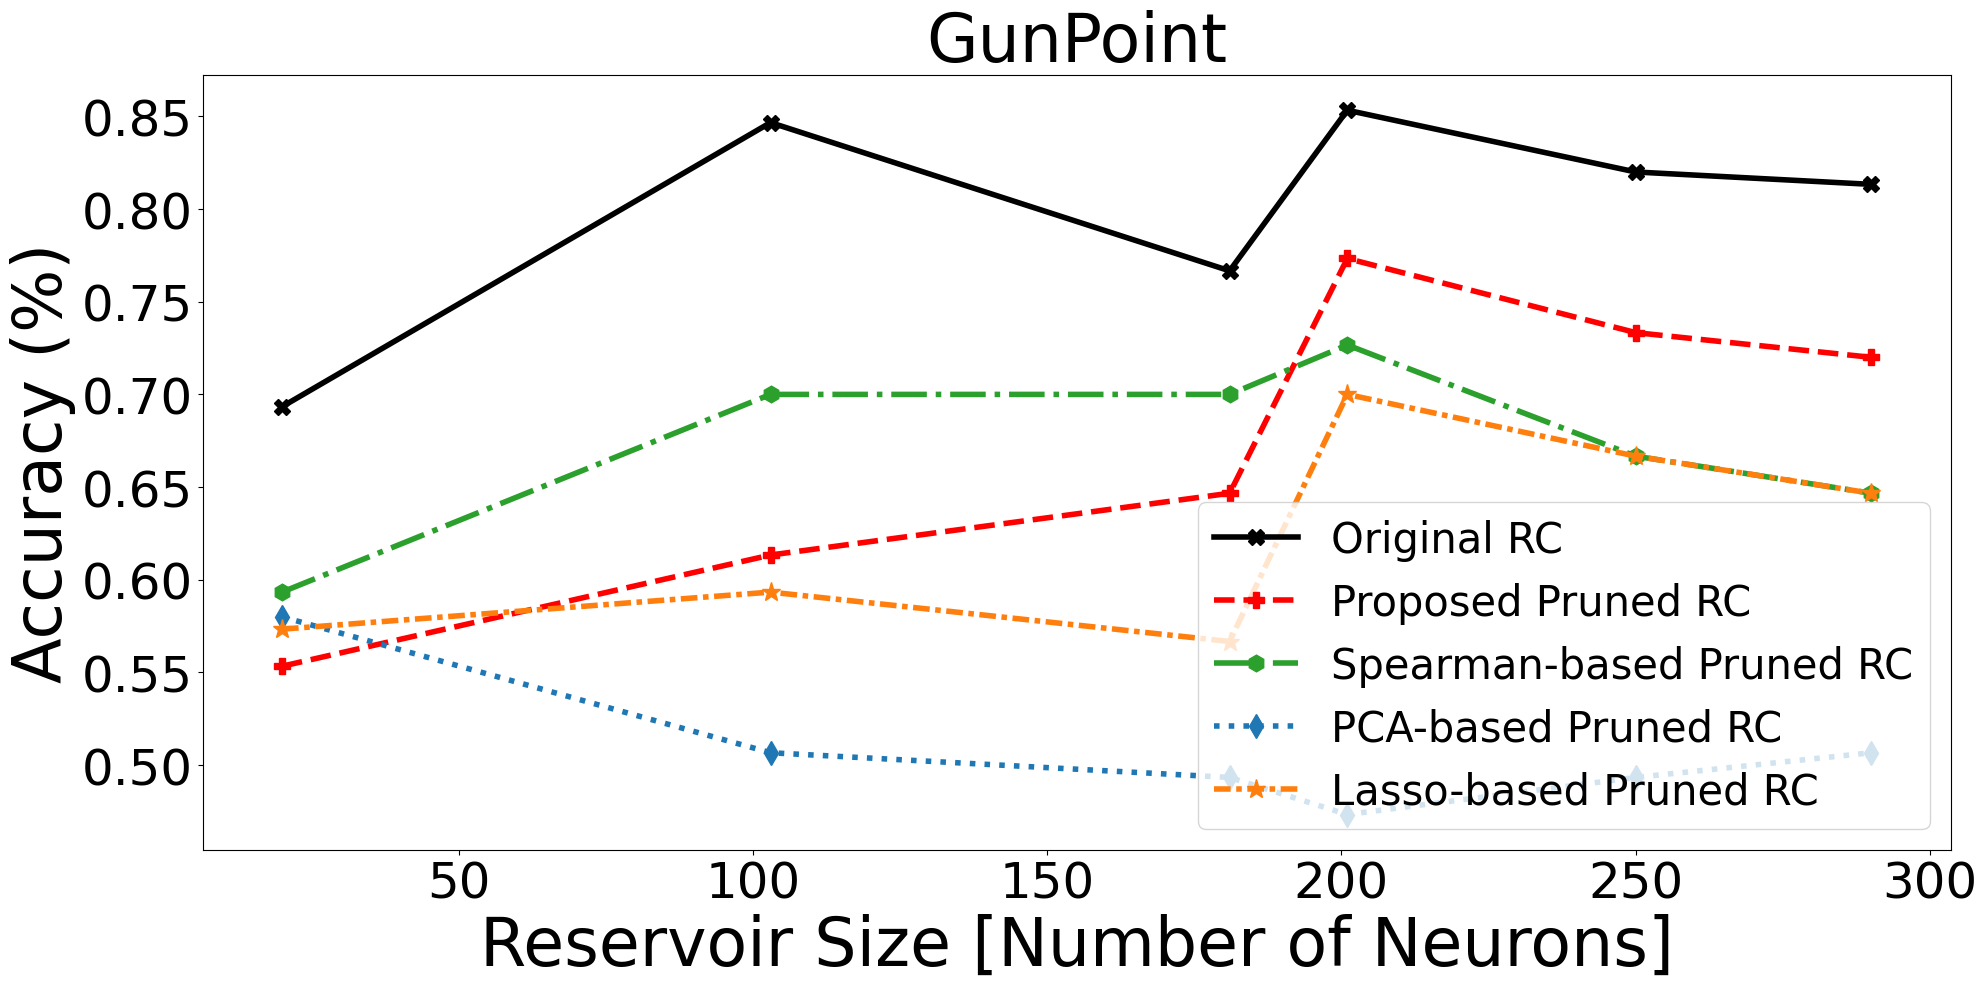

In [546]:
import matplotlib.pyplot as plt
import numpy as np

# Sample data (replace with actual results)
sizes = [result['N'] for result in results]
accuracy_original_vals = [result['accuracy'] for result in results]
accuracy_HSIC_vals = [result['accuracy_HSIC'] for result in results]
accuracy_Spearman_vals = [result['accuracy_Spearman'] for result in results]
accuracy_PCA_vals = [result['accuracy_PCA'] for result in results]
accuracy_Lasso_vals = [result['accuracy_Lasso'] for result in results]

plt.figure(figsize=(20, 10))

# Updated color scheme with distinct styles and markers
plt.plot(sizes, accuracy_original_vals, label='Original RC', linestyle='-', marker='X', color='black', linewidth=4, markersize=12)  # Black solid line with X marker
plt.plot(sizes, accuracy_HSIC_vals, label='Proposed Pruned RC', linestyle='--', marker='P', color='red', linewidth=4, markersize=12)  # Red dashed line with P marker
plt.plot(sizes, accuracy_Spearman_vals, label='Spearman-based Pruned RC', linestyle='-.', marker='h', color='#2ca02c', linewidth=4, markersize=12)  # Green dash-dot with hexagon marker
plt.plot(sizes, accuracy_PCA_vals, label='PCA-based Pruned RC', linestyle=':', marker='d', color='#1f77b4', linewidth=4, markersize=12)  # Blue dotted line with diamond marker
plt.plot(sizes, accuracy_Lasso_vals, label='Lasso-based Pruned RC', linestyle=(0, (3, 1, 1, 1)), marker='*', color='#ff7f0e', linewidth=4, markersize=14)  # Orange custom dashed with star marker

# Labels and title
plt.xlabel('Reservoir Size [Number of Neurons]', fontsize=48)
plt.ylabel('Accuracy (%)', fontsize=48)
plt.title('GunPoint', fontsize=48)

# Legend and grid
plt.legend(fontsize=30, loc='lower right')
# plt.grid(True, linestyle='--', linewidth=1.9, alpha=0.6, color='gray')  # Applied grid with custom styling

# Tick settings
plt.xticks(fontsize=36)
plt.yticks(fontsize=36)

# Adjust x-axis ticks for better readability
# plt.xticks(np.arange(min(sizes), max(sizes)+1, 50))
import webbrowser
webbrowser.open("GunPoint.pdf") 
# Save plot
plt.tight_layout()
plt.savefig("GunPoint.pdf", bbox_inches='tight')
plt.savefig("GunPoint.pdf", bbox_inches='tight')

plt.show()


In [540]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from brevitas.nn import QuantHardTanh, QuantIdentity, QuantLinear
from brevitas.quant import Int8ActPerTensorFloat, Int8WeightPerTensorFloat
from reservoirpy.datasets import mackey_glass
from reservoirpy.nodes import Reservoir, Ridge
from reservoirpy.observables import rmse, rsquare
from reservoirpy import Node
import reservoirpy as rpy
rpy.verbosity(0)
rpy.set_seed(42)
pruned_res_size = len(ind)

# Parameters
N = pruned_res_size #reservoir size
bit_width = 8 # quantization bit width
#integer, out , scale,  quantizer, layer , ...
# input

from brevitas.nn import QuantIdentity
import math
def extract_Qinput(input, num_bits=8):
  quant_identity = QuantIdentity(return_quant_tensor=True,bit_width=num_bits)
  float_input = torch.tensor(input,dtype=torch.float64)
  quant_input = quant_identity(float_input)
  out = quant_input.int().detach().numpy()

  scale = quant_input.scale.detach().numpy()
  zero_point = quant_input.zero_point.numpy()
  print(f"Input int quantized:\n {out} \n")
  print(f"Input scale: {scale}")
  print(f"Input zero_point: {zero_point}")
  return out, scale, zero_point
from brevitas.nn import QuantLinear
from brevitas.quant import Int8ActPerTensorFloat,Int8WeightPerTensorFloat
import math


def quantize_output_layer(weights, num_bits=8):
  quant_linear = QuantLinear(2, 4,weight_bit_width=num_bits, weight_quant=Int8WeightPerTensorFloat, requires_grad=False)
  quant_linear.weight.data = torch.tensor(weights,dtype=torch.float64)

  out = quant_linear.quant_weight().int().detach().numpy()
  scale = quant_linear.quant_weight().scale.detach().numpy()
  # out = quant_linear.quant_weight().value.data.numpy()


  #out = out * 0

  return out,scale

int_x,x_scale,x_zero_point = extract_Qinput(X,num_bits=bit_width)
# np.savetxt('input_data.csv', int_x[5002:], fmt='%s', delimiter=',')
print('Extract quantized integer Win and Scale and Zero_point')
int_Win,scale_Win,zero_point_Win = extract_Qinput(esn_model_pruned.nodes[0].Win.todense(),num_bits=bit_width)
print('Extract quantized integer Wr and Scale and Zero_point')
int_Wr,scale_Wr,zero_point_Wr = extract_Qinput(esn_model_pruned.nodes[0].W.todense(),num_bits=bit_width)
int_bias, scale_bias, zero_point_bias = extract_Qinput(esn_model_pruned.nodes[0].bias.todense(), num_bits=bit_width)


input_scale = (scale_Win * x_scale)
threshold_scale = 0.0078125
reservoir_scale = (scale_Wr * threshold_scale)

def compute_integer_thresholds(scale):

    a = -1  # Lower bound of Hard Tanh
    b = 1   # Upper bound of Hard Tanh
    a_scaled = np.int32(a / scale)
    b_scaled = np.int32(b / scale)
    return a_scaled, b_scaled

def piecewise_linear_hard_tanh_integer(x, a_scaled, b_scaled):

    # Apply saturation logic
    x = np.where(x < a_scaled, a_scaled, x)
    x = np.where(x > b_scaled, b_scaled, x)
    x=x + b_scaled
    return (x / 256).astype(np.int32)

a_scaled, b_scaled = compute_integer_thresholds(input_scale)
c_scaled, d_scaled = compute_integer_thresholds(reservoir_scale)

from reservoirpy import Node
def forward2(node: Node, x: np.ndarray) -> np.ndarray:
    state = node.state()  # get current node state  # Current reservoir state as integer
    state_int = state.astype(np.int64)
    W_res = node.Wr
    W_in = node.Win
    bias_res = node.Bias
    state_int = state_int.reshape(1,N)

    r = state_int @ W_res.astype(np.int32)
    s = x @ W_in.astype(np.int32).T
    s = s.reshape(1,N)
    # Precompute thresholds and scale
    # a_scaled, b_scaled = compute_integer_thresholds(scale_Wr)
    bias_res = bias_res.reshape(1, N)



    # Apply integer PLA to reservoir and input contributions
    out_r = piecewise_linear_hard_tanh_integer(s,a_scaled, b_scaled)
    out_s = piecewise_linear_hard_tanh_integer(r,c_scaled, d_scaled)

    return out_r + out_s 

def initialize(node: Node, x: np.ndarray = None, y: np.ndarray = None):
    """This function receives a data point x at runtime and uses it to
    infer input and output dimensions.
    """
    if x is not None:
        node.set_input_dim(x.shape[1])
        node.set_output_dim(N)
        node.set_param("Wr", int_Wr)
        node.set_param("Win", int_Win)
        node.set_param("Bias", int_bias)

class CustomNode(Node):
    def __init__(self, const2=-1, name=None):
        super().__init__(
            forward=forward2,
            initializer=initialize,

            params={"const1": None, "Wr":None, "Win":None, "Bias":None},
            hypers={"const2": const2},
            name=name,
        )

node = CustomNode(const2=-1, name="custom_node3")
# readout_pruned.ridge = 1e-12

esn_model_PTQ = node >> readout_pruned

Quantized_States = node.run(int_x[:1000].astype(np.float64))

Quantized_States = Quantized_States * threshold_scale
readout_pruned.fit(Quantized_States.astype(np.float64), y_train_cat)
# esn_model_PTQ = node >> readout_pruned

# esn_model_PTQ = esn_model_PTQ.fit(int_x[:5000].astype(np.float64), int_x[1:5001].astype(np.float64), warmup=1000)

Quantized_States = node.run(int_x[1000:].astype(np.float64))
Quantized_States = Quantized_States * threshold_scale
Y_pred_PTQ = readout_pruned.run(Quantized_States.astype(np.float64))
# min_pred = np.min(Y_pred_PTQ)
# max_pred = np.max(Y_pred_PTQ)
# Y_pred_PTQ_normalized = 2 * (Y_pred_PTQ - min_pred) / (max_pred - min_pred) - 1

# Wout_quantized, scale_out = quantize_output_layer(readout.Wout,num_bits=bit_width)
# readout.Wout = Wout_quantized

# a=threshold_scale * scale_out

# Y_pred_PTQ = esn_model_PTQ.run(int_x[5001:-1])
# Y_pred_PTQ = Y_pred_PTQ *a
Y_pred_PTQ = np.argmax(Y_pred_PTQ, axis=1)
accuracy_PTQ = np.mean(Y_pred_PTQ == y_test_labels)
print(f"Test accuracy PQ: {accuracy_PTQ * 100:.5f}%")


NameError: name 'ind' is not defined